# **Criação do operador XOR aplicado à fusão multimodal**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
a = [1, 2, 3, 4, 5]
b = [6, 7, 8, 9, 10]
d = []


for i in range(5):
  c = a[i]^b[i]
  d.append(c)

print(d, "o resultado está conforme o esperado")

[7, 5, 11, 13, 15] o resultado está conforme o esperado


### **Agora, será feira a função do XOR para ser aplicada à base de vídeos**

In [1]:
def xorOperator (visual, aural):
  xorFused =[]

  for i in range(len(visual)):
    a = aural[i]
    v = visual[i]
    xorFused.append(aural[i]^visual[i])

  return (xorFused)

In [2]:
def xorOperator2(visual, aural):
    #xorFused = visual.copy()
    xorFused = []
    xorList = []
    qtdTomadas = len(visual)
    tamHist = len(visual[0])

    print("TamHist: ", tamHist)
    print("visual: ",len(visual[0]), visual[0])
    print("aural: ", aural[0])

    for tomada in range(qtdTomadas):
        v = visual[tomada]
        a = aural[tomada]
        for i in range (tamHist):
            xorFused.append(int(a[i])^int(v[i]))
        xorList.append(xorFused)
        xorFused = []
    print("Xor: ", len(xorList[0]), xorList[0])
    return (xorList)

### ** testando a função para o mesmo caso anterior **

In [ ]:
a = [1, 2, 3, 4, 5]
b = [6, 7, 8, 9, 10]
d = []

d = xorOperator(a, b)
print(d,";",a,";", b, "o resultado continua dentro daquilo esperado")

[7, 5, 11, 13, 15] ; [1, 2, 3, 4, 5] ; [6, 7, 8, 9, 10] o resultado continua dentro daquilo esperado


# Agora, aplicar essa função na fusão multimodal

## Preparação do ambiente do Notebook





**Instalando Dependências**

In [3]:
import numpy as np
import pickle
import matplotlib.pyplot as plt


**Acesso ao Drive - para armazenamento de Arquivos**

In [4]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)


Mounted at /content/drive


TamHist:  100
visual:  100 [0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 4. 0.
 0. 2. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 3. 0. 0. 0. 2. 0.
 0. 0. 0. 0. 0. 1. 0. 2. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 2. 0. 2.
 0. 0. 0. 0. 0. 3. 0. 0. 2. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 2. 0. 0. 0. 0.
 0. 0. 0. 0.]
aural:  [  0.   1.  21.   0.   0.   0.   0.   1.   0.   0.  12.   0.   0.   0.
   0.  77.   0.   0.   0.   0.   0.   0.   0. 307.   0.   1.  44.   0.
   0.   0.   0.   0.  76.   0.   0.   0.   3.   0.   0.   0.  89.  45.
   0.   0. 154. 209.   1.   0.   0.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   1.  21.  38.   0.   0.   0.   0.   0.   0.   0.
   0.   0.   0.   0.   0.   0.   0.   0.   0.   4.   0.   7.   0.   7.
   2.   0.   0.   0.   0.  51.   0.   1.   0.   0.  11.   0.  84.   0.
   0.   0.]
Xor:  100 [0, 1, 20, 0, 0, 0, 0, 1, 0, 1, 12, 0, 0, 0, 0, 77, 0, 0, 0, 0, 0, 0, 4, 307, 0, 3, 44, 0, 1, 0, 0, 0, 76, 0, 0, 0, 3, 0, 0, 0, 89, 45, 3, 0

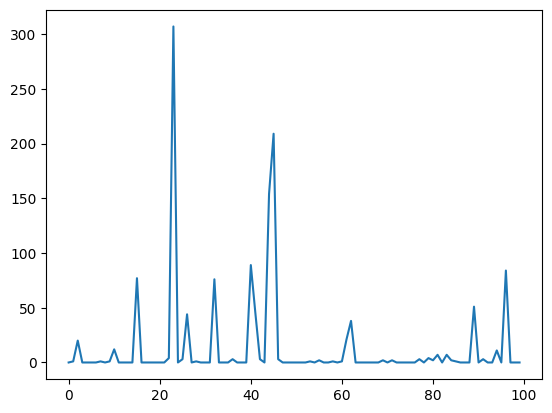

In [7]:
visualHistogram = []

#Recuperando representação monomodal visual previamente computada e salva em arquivo
#O número ao fim do nome do arquivo indica a dimesão de cada histograma, que vem
#do tamanho do dicionário usado para gerar a representação monomodal.
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Visuais/visual_histogram_100_cosine_bbc_10.arq', 'rb') as arq1:
#with open('/content/drive/MyDrive/Dataset_BBC/Histograms/visual_histogram_bbc_01_100_cosine.arq', 'rb') as arq1:
    visualHistogram = pickle.load(arq1)


#Idem para a reprensentação monomodal aural.
auralHistogram = []
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Aurais/aural_histogram_100_cosine_bbc_10.arq', 'rb') as arq2:
#with open('/content/drive/MyDrive/Dataset_BBC/Histograms/aural_histogram__bbc_01_100_cosine.arq', 'rb') as arq2:
    auralHistogram = pickle.load(arq2)

#Aplicando o operador de fusão.
multiModalHistogram = xorOperator2(visualHistogram, auralHistogram)

#Salvado  os histogramas em arquivo
#A pasta "histogramas" deve existir dentro de "MBA_Curso14_Dados"
with open('/content/drive/MyDrive/DatasetBBC_Leticia/Histogramas/Histogramas_Multimodais_XOR/mm_xor_histogram_bbc_10_100_cosine.arq', 'wb') as arq_mm:
#with open('/content/drive/MyDrive/Dataset_BBC/Histograms/mm_xor_histogram_bbc_01_100_cosine.arq', 'wb') as arq_mm:
    pickle.dump(multiModalHistogram, arq_mm)

#Imprimindo o histograma multimodal do 1o vídeo da base
print("Multimodal: ", multiModalHistogram[0])

plt.plot(multiModalHistogram[0])
plt.show()